<a href="https://colab.research.google.com/github/Joshika-Reddy/Spam-Email-Detection/blob/main/ML_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SPAM EMAIL DETECTION**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spam[1].csv to spam[1].csv


In [ ]:
import pandas as pd

data = pd.read_csv("spam[1].csv", encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
data = data[['v1', 'v2']]
data.columns = ['label', 'message']

In [ ]:
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Convert labels
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

# Clean text
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    return text

data['message'] = data['message'].apply(clean_text)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    data['message'], data['label'], test_size=0.2, random_state=42)

# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predict
y_pred = model.predict(X_test_vec)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.967713004484305

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



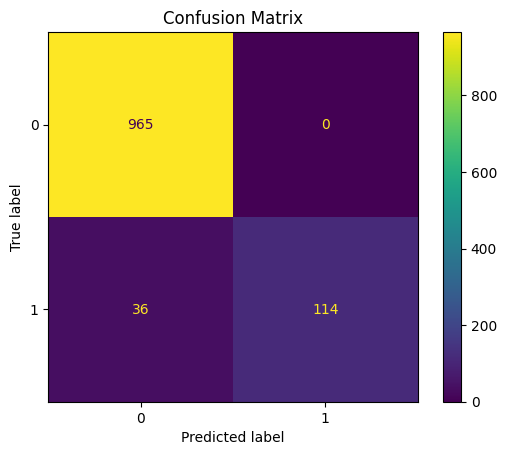

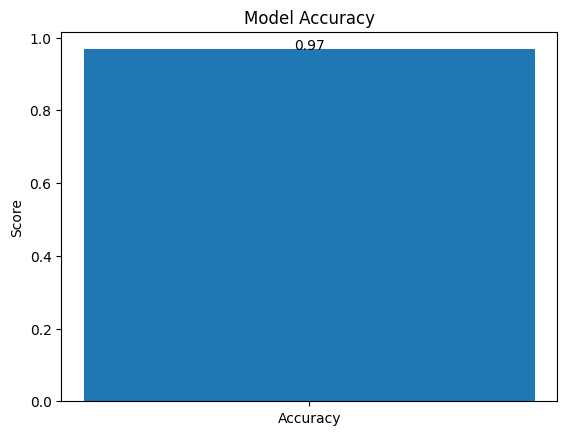

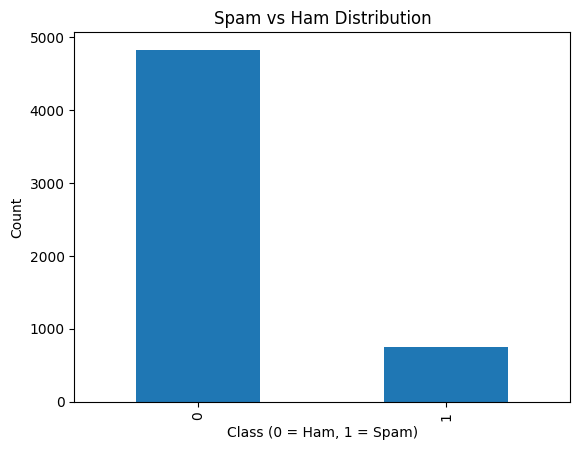

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 🔹 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# 🔹 Accuracy Bar Graph
accuracy = accuracy_score(y_test, y_pred)
plt.bar(["Accuracy"], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Score")

# Add value text
plt.text(0, accuracy, round(accuracy, 2), ha='center')
plt.show()

# 🔹 Spam vs Ham Distribution
data['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Count")
plt.show()

In [ ]:
samples = [
    "Win a free iPhone now!!!",
    "Can you send me the notes?",
    "Congratulations! Claim your reward",
    "Let's meet for lunch tomorrow"
]

samples_vec = vectorizer.transform(samples)
predictions = model.predict(samples_vec)

for msg, pred in zip(samples, predictions):
    print(msg, "=>", "Spam" if pred == 1 else "Not Spam")

Win a free iPhone now!!! => Spam
Can you send me the notes? => Not Spam
Congratulations! Claim your reward => Spam
Let's meet for lunch tomorrow => Not Spam
